# Practical 10 — Data Visualization III

## Objective
Analyze the Iris dataset by examining feature distributions through histograms and box plots, identifying outliers and comparing distributions.

## Step 1: Import Libraries and Load Dataset

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("Libraries imported successfully!")

Libraries imported successfully!


In [29]:
# Load the Iris dataset
df = pd.read_csv('Iris.csv')

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

print("\nFirst 10 rows of the dataset:")
df.head(10)

Dataset loaded successfully!
Dataset shape: (150, 6)
Number of rows: 150
Number of columns: 6

First 10 rows of the dataset:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


## Step 2: Feature Analysis - Types and Characteristics

In [30]:
print("="*70)
print("FEATURE ANALYSIS")
print("="*70)

print("\n1. DATASET INFORMATION:")
print("-" * 70)
df.info()

FEATURE ANALYSIS

1. DATASET INFORMATION:
----------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [31]:
print("\n2. FEATURES AND THEIR TYPES:")
print("-" * 70)

print("\nColumn Names and Data Types:")
for col in df.columns:
    print(f"   {col}: {df[col].dtype}")

print("\nFeature Classification:")
print("\n   NUMERIC FEATURES (Continuous):")
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
for feature in numeric_features:
    print(f"      - {feature}")

print("\n   NOMINAL/CATEGORICAL FEATURES:")
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
if categorical_features:
    for feature in categorical_features:
        print(f"      - {feature} (Unique values: {df[feature].nunique()})")
else:
    print("      None")

print("\n" + "="*70)


2. FEATURES AND THEIR TYPES:
----------------------------------------------------------------------

Column Names and Data Types:
   Id: int64
   SepalLengthCm: float64
   SepalWidthCm: float64
   PetalLengthCm: float64
   PetalWidthCm: float64
   Species: str

Feature Classification:

   NUMERIC FEATURES (Continuous):
      - Id
      - SepalLengthCm
      - SepalWidthCm
      - PetalLengthCm
      - PetalWidthCm

   NOMINAL/CATEGORICAL FEATURES:
      - Species (Unique values: 3)



In [32]:
print("\n3. DESCRIPTIVE STATISTICS:")
print("-" * 70)
print("\nSummary Statistics for Numeric Features:")
df[numeric_features].describe().round(2)


3. DESCRIPTIVE STATISTICS:
----------------------------------------------------------------------

Summary Statistics for Numeric Features:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.00,150.00,150.00,150.00,150.00
mean,75.50,5.84,3.05,3.76,1.20
std,43.45,0.83,0.43,1.76,0.76
min,1.00,4.30,2.00,1.00,0.10
25%,38.25,5.10,2.80,1.60,0.30
50%,75.50,5.80,3.00,4.35,1.30
75%,112.75,6.40,3.30,5.10,1.80
max,150.00,7.90,4.40,6.90,2.50


In [33]:
print("\n4. MISSING VALUES CHECK:")
print("-" * 70)
print("\nMissing values per column:")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

if missing.sum() == 0:
    print("\nDataset is complete with no missing values!")
else:
    print("\nDataset contains missing values. Data cleaning required.")

print("\n" + "="*70)


4. MISSING VALUES CHECK:
----------------------------------------------------------------------

Missing values per column:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Total missing values: 0

Dataset is complete with no missing values!



## Step 3: Histograms - Feature Distributions

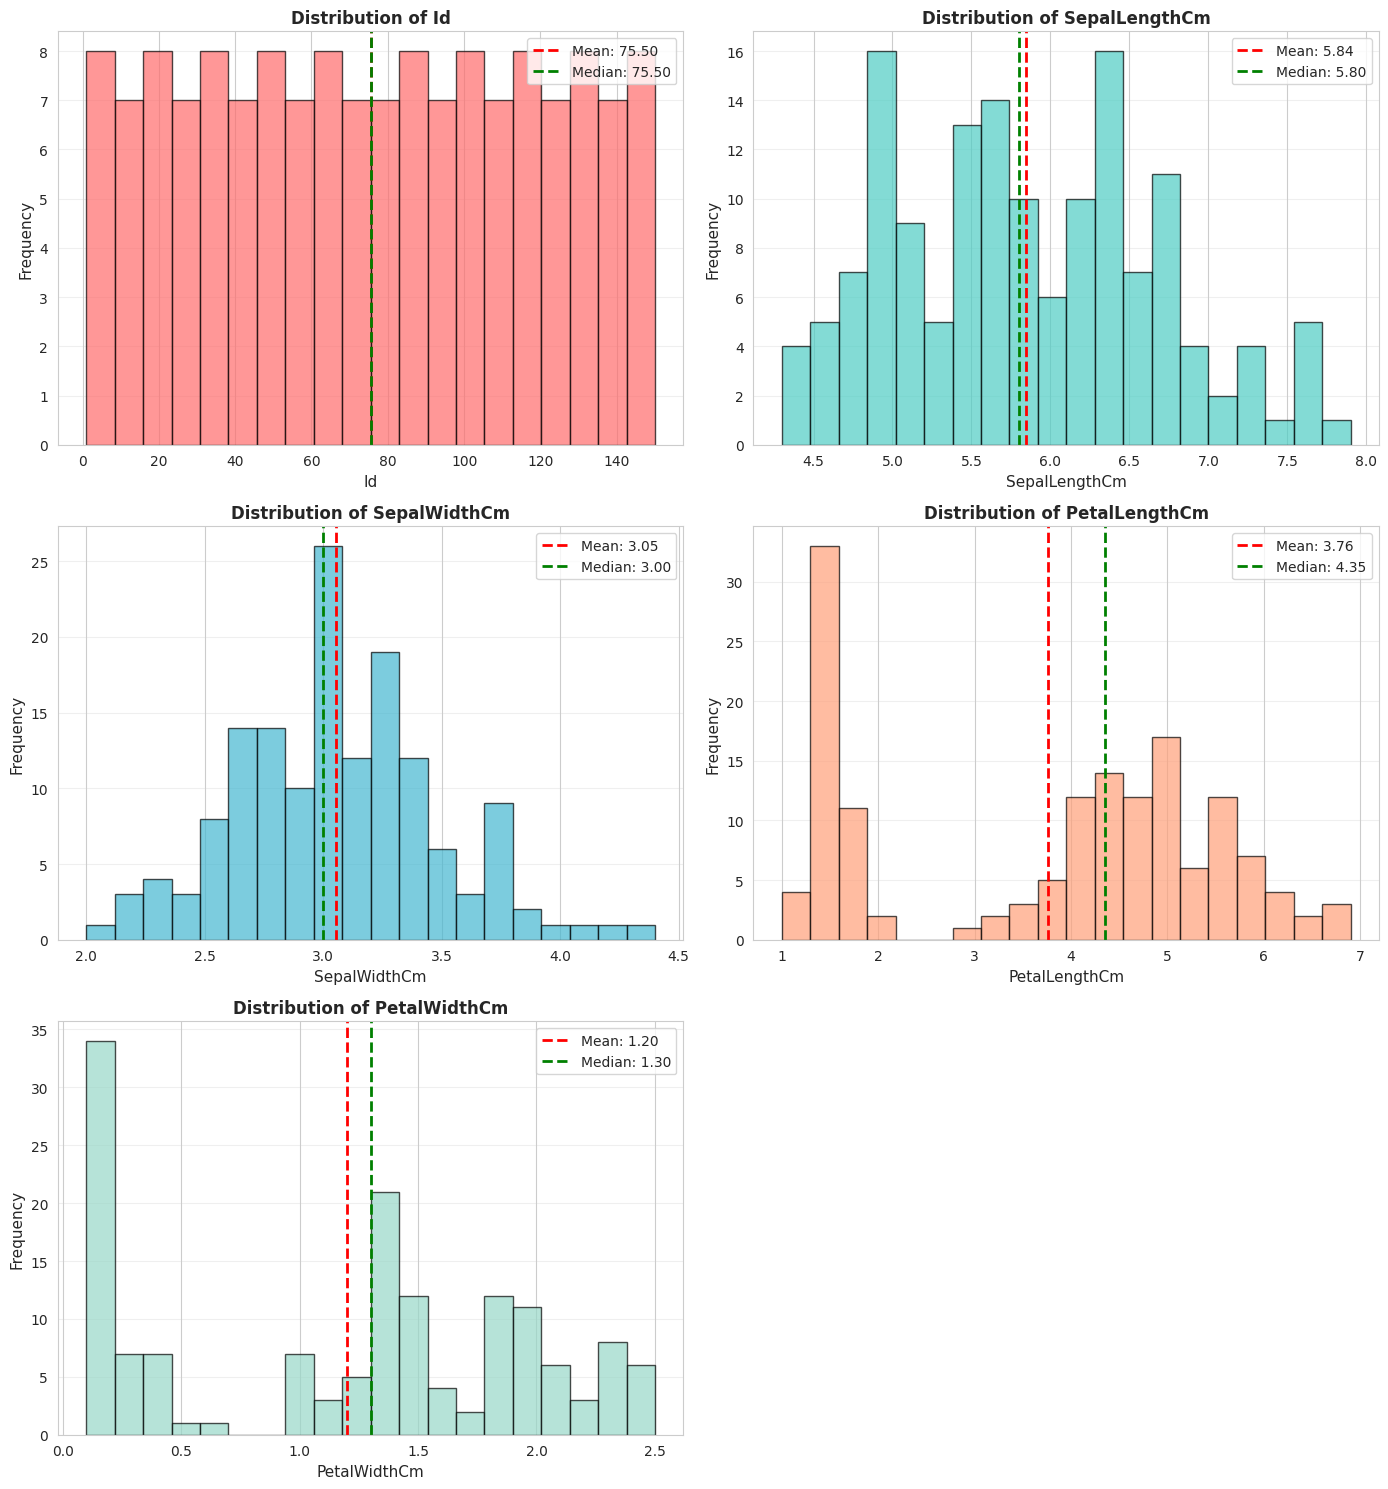

In [34]:
# Create individual histograms for each numeric feature
# Dynamically determine grid size
n_features = len(numeric_features)
n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols  # Ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
axes = axes.ravel()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F']

for idx, feature in enumerate(numeric_features):
    axes[idx].hist(df[feature], bins=20, color=colors[idx % len(colors)], alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Add statistics on histogram
    mean_val = df[feature].mean()
    median_val = df[feature].median()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
    axes[idx].legend()

# Hide extra subplots if any
for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

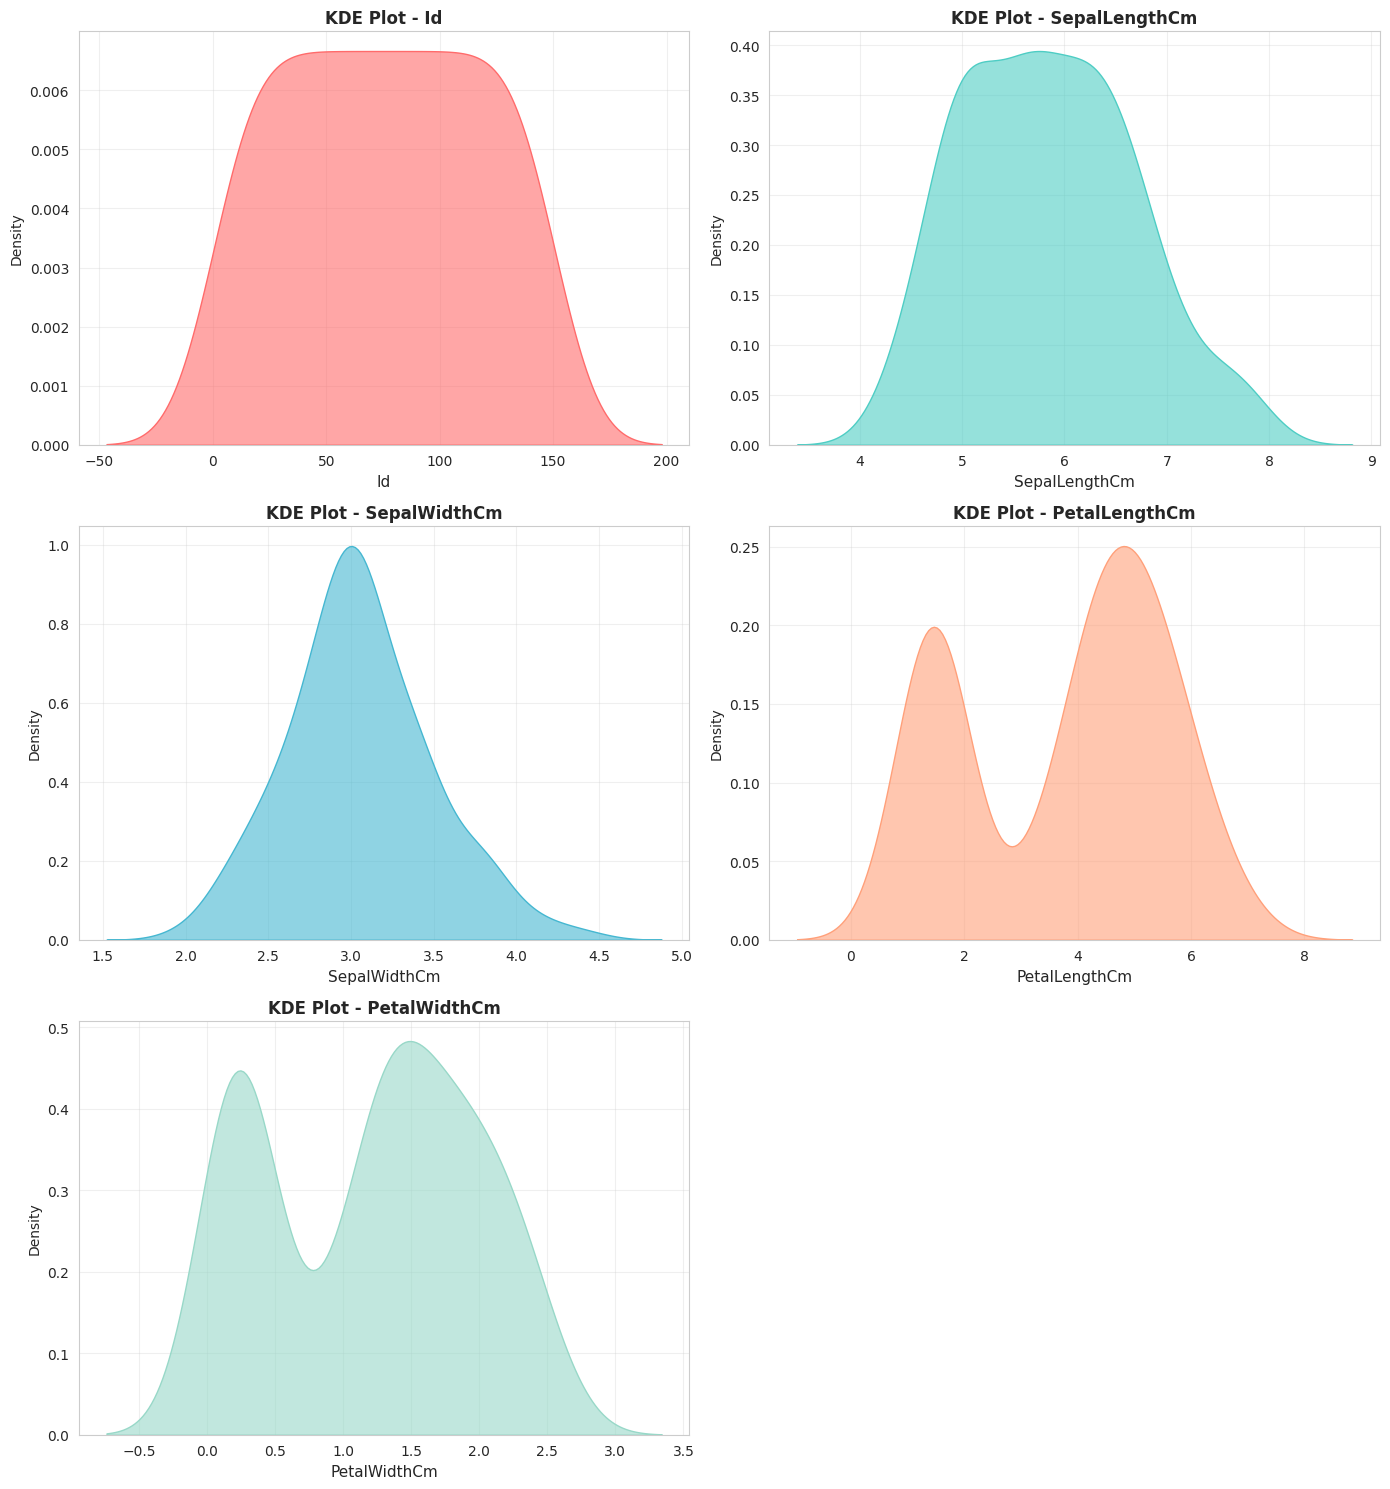


Histograms and KDE plots generated successfully!


In [35]:
# KDE plots for smooth distribution visualization
# Dynamically determine grid size
n_features = len(numeric_features)
n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
axes = axes.ravel()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F']

for idx, feature in enumerate(numeric_features):
    sns.kdeplot(data=df, x=feature, ax=axes[idx], fill=True, color=colors[idx % len(colors)], alpha=0.6)
    axes[idx].set_title(f'KDE Plot - {feature}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].grid(alpha=0.3)

# Hide extra subplots if any
for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

print("\nHistograms and KDE plots generated successfully!")

## Step 4: Box Plots - Quartile and Outlier Analysis

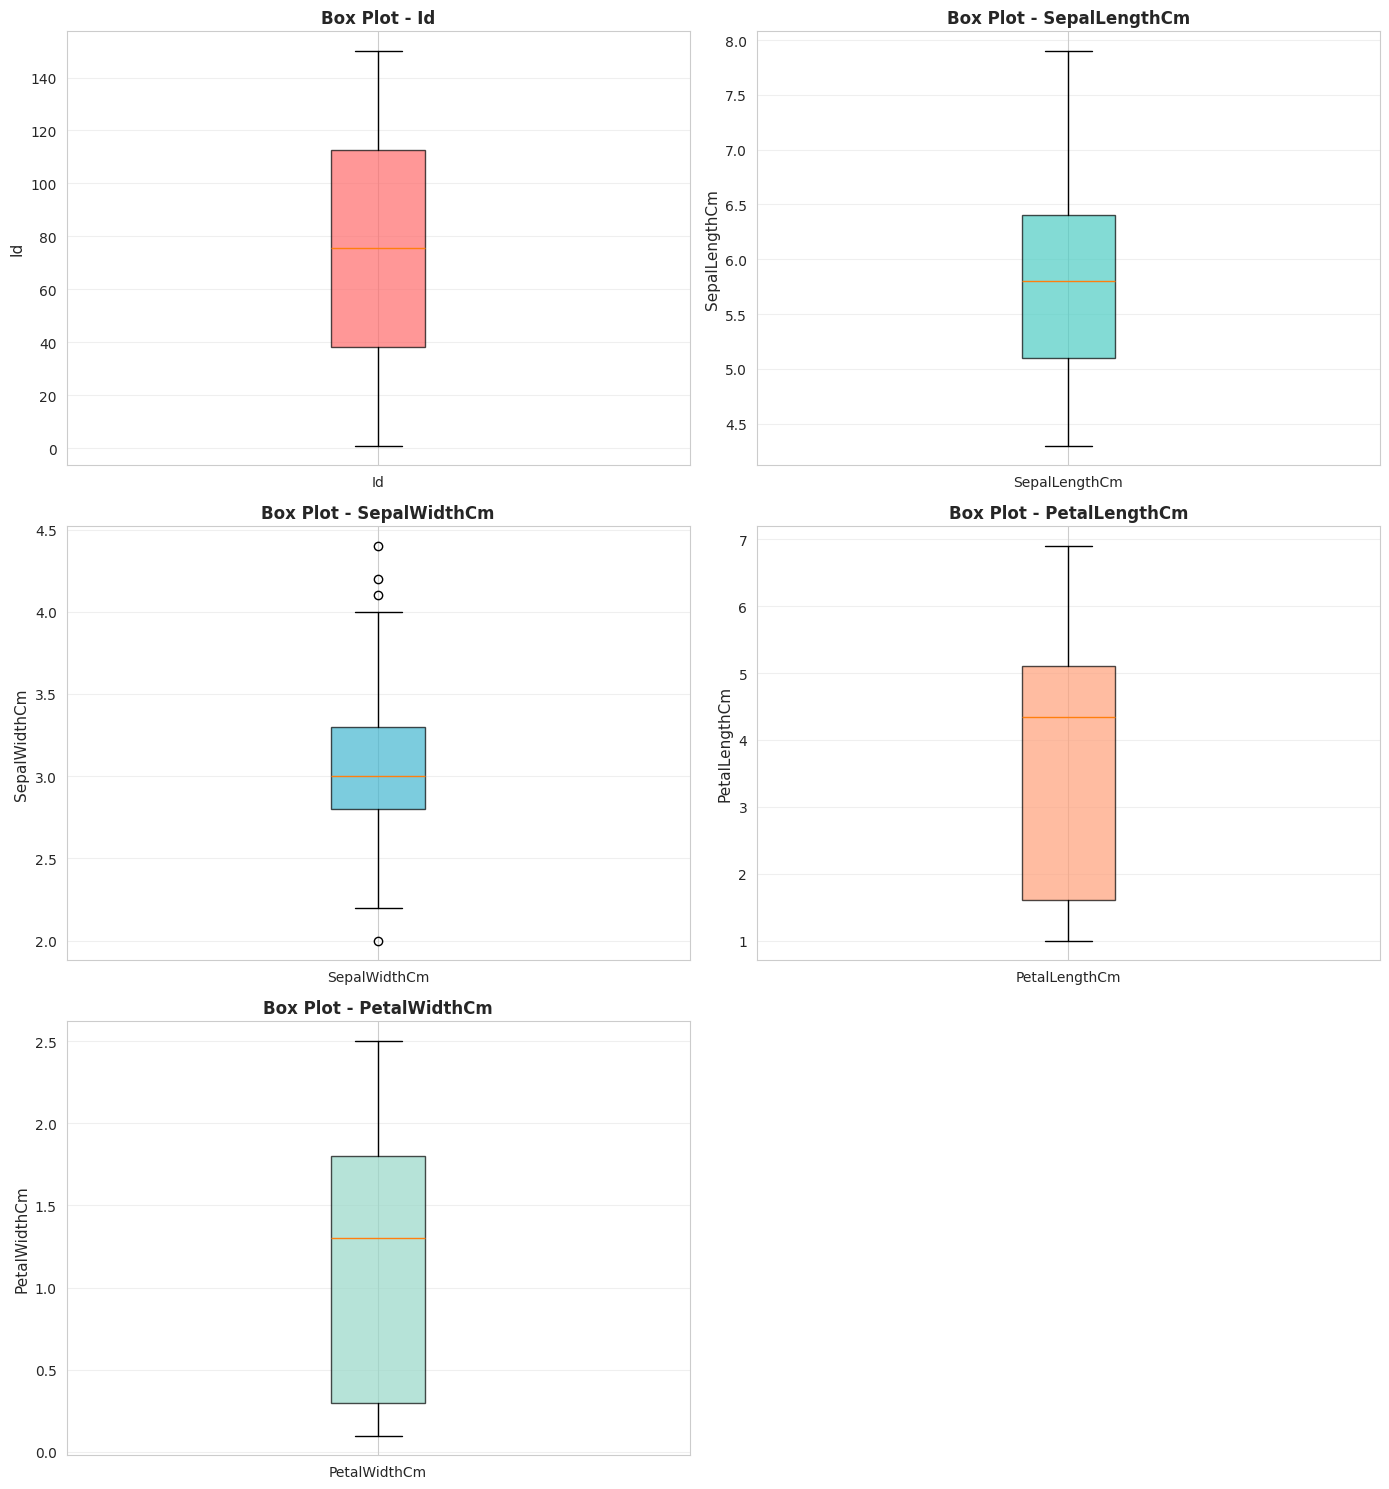

Box plots generated successfully!


In [36]:
# Create box plots for each numeric feature
# Dynamically determine grid size
n_features = len(numeric_features)
n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
axes = axes.ravel()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F']

for idx, feature in enumerate(numeric_features):
    bp = axes[idx].boxplot([df[feature]], labels=[feature], patch_artist=True)
    bp['boxes'][0].set_facecolor(colors[idx % len(colors)])
    bp['boxes'][0].set_alpha(0.7)
    axes[idx].set_title(f'Box Plot - {feature}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(feature, fontsize=11)
    axes[idx].grid(axis='y', alpha=0.3)

# Hide extra subplots if any
for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

print("Box plots generated successfully!")

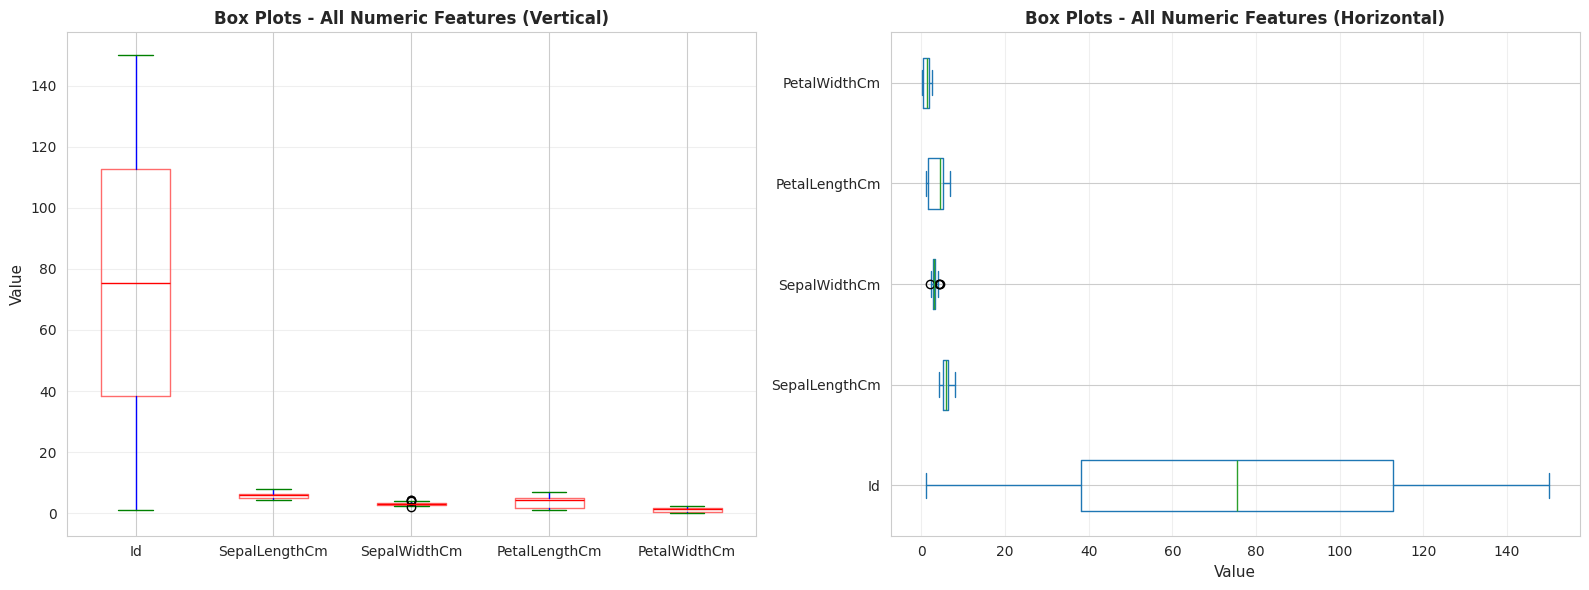

In [37]:
# Alternative box plot using seaborn for better visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Vertical box plots
df[numeric_features].plot(kind='box', ax=axes[0], color=dict(boxes=colors[0], whiskers='blue', medians='red', caps='green'))
axes[0].set_title('Box Plots - All Numeric Features (Vertical)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Value', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Horizontal box plots
df[numeric_features].plot(kind='box', ax=axes[1], vert=False)
axes[1].set_title('Box Plots - All Numeric Features (Horizontal)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Value', fontsize=11)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Step 5: Outlier Detection and Analysis

In [38]:
print("="*70)
print("OUTLIER ANALYSIS")
print("="*70)

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound, IQR

for feature in numeric_features:
    outliers, lower_bound, upper_bound, iqr = detect_outliers_iqr(df, feature)
    print(f"\n{feature}:")
    print(f"   Q1 (25th percentile): {df[feature].quantile(0.25):.2f}")
    print(f"   Q3 (75th percentile): {df[feature].quantile(0.75):.2f}")
    print(f"   IQR (Interquartile Range): {iqr:.2f}")
    print(f"   Lower Bound: {lower_bound:.2f}")
    print(f"   Upper Bound: {upper_bound:.2f}")
    print(f"   Number of Outliers: {len(outliers)}")
    if len(outliers) > 0:
        print(f"   Outlier values: {sorted(outliers[feature].values)}")
    else:
        print(f"   No outliers detected")

print("\n" + "="*70)

OUTLIER ANALYSIS

Id:
   Q1 (25th percentile): 38.25
   Q3 (75th percentile): 112.75
   IQR (Interquartile Range): 74.50
   Lower Bound: -73.50
   Upper Bound: 224.50
   Number of Outliers: 0
   No outliers detected

SepalLengthCm:
   Q1 (25th percentile): 5.10
   Q3 (75th percentile): 6.40
   IQR (Interquartile Range): 1.30
   Lower Bound: 3.15
   Upper Bound: 8.35
   Number of Outliers: 0
   No outliers detected

SepalWidthCm:
   Q1 (25th percentile): 2.80
   Q3 (75th percentile): 3.30
   IQR (Interquartile Range): 0.50
   Lower Bound: 2.05
   Upper Bound: 4.05
   Number of Outliers: 4
   Outlier values: [np.float64(2.0), np.float64(4.1), np.float64(4.2), np.float64(4.4)]

PetalLengthCm:
   Q1 (25th percentile): 1.60
   Q3 (75th percentile): 5.10
   IQR (Interquartile Range): 3.50
   Lower Bound: -3.65
   Upper Bound: 10.35
   Number of Outliers: 0
   No outliers detected

PetalWidthCm:
   Q1 (25th percentile): 0.30
   Q3 (75th percentile): 1.80
   IQR (Interquartile Range): 1.50
   

## Step 6: Distribution Comparison and Analysis

In [39]:
print("="*70)
print("DISTRIBUTION COMPARISON AND ANALYSIS")
print("="*70)

print("\n1. DISTRIBUTION SHAPE ANALYSIS:")
print("-" * 70)

for feature in numeric_features:
    data = df[feature]
    mean = data.mean()
    median = data.median()
    std = data.std()
    skewness = data.skew()
    kurtosis = data.kurtosis()
    
    print(f"\n{feature}:")
    print(f"   Mean: {mean:.3f}, Median: {median:.3f}, Std Dev: {std:.3f}")
    print(f"   Skewness: {skewness:.3f}", end="")
    if abs(skewness) < 0.5:
        print(" (Fairly Symmetric)")
    elif skewness > 0.5:
        print(" (Right-skewed)")
    else:
        print(" (Left-skewed)")
    
    print(f"   Kurtosis: {kurtosis:.3f}", end="")
    if kurtosis < -1:
        print(" (Platykurtic - Flatter)")
    elif kurtosis > 1:
        print(" (Leptokurtic - More peaked)")
    else:
        print(" (Mesokurtic - Normal-like)")
    
    print(f"   Range: [{data.min():.2f}, {data.max():.2f}]")
    print(f"   CV (Coeff. of Variation): {(std/mean)*100:.2f}%")

print("\n" + "="*70)

DISTRIBUTION COMPARISON AND ANALYSIS

1. DISTRIBUTION SHAPE ANALYSIS:
----------------------------------------------------------------------

Id:
   Mean: 75.500, Median: 75.500, Std Dev: 43.445
   Skewness: 0.000 (Fairly Symmetric)
   Kurtosis: -1.200 (Platykurtic - Flatter)
   Range: [1.00, 150.00]
   CV (Coeff. of Variation): 57.54%

SepalLengthCm:
   Mean: 5.843, Median: 5.800, Std Dev: 0.828
   Skewness: 0.315 (Fairly Symmetric)
   Kurtosis: -0.552 (Mesokurtic - Normal-like)
   Range: [4.30, 7.90]
   CV (Coeff. of Variation): 14.17%

SepalWidthCm:
   Mean: 3.054, Median: 3.000, Std Dev: 0.434
   Skewness: 0.334 (Fairly Symmetric)
   Kurtosis: 0.291 (Mesokurtic - Normal-like)
   Range: [2.00, 4.40]
   CV (Coeff. of Variation): 14.20%

PetalLengthCm:
   Mean: 3.759, Median: 4.350, Std Dev: 1.764
   Skewness: -0.274 (Fairly Symmetric)
   Kurtosis: -1.402 (Platykurtic - Flatter)
   Range: [1.00, 6.90]
   CV (Coeff. of Variation): 46.94%

PetalWidthCm:
   Mean: 1.199, Median: 1.300, St

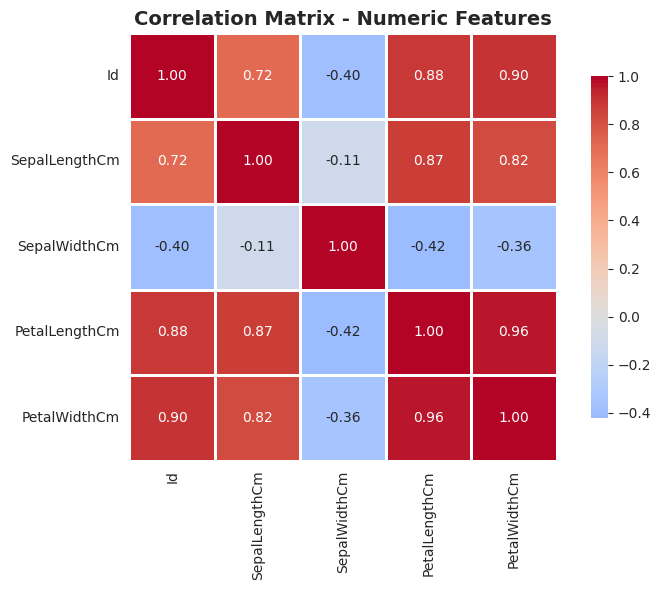


Correlation Matrix:
                  Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
Id             1.000          0.717        -0.398          0.883         0.900
SepalLengthCm  0.717          1.000        -0.109          0.872         0.818
SepalWidthCm  -0.398         -0.109         1.000         -0.421        -0.357
PetalLengthCm  0.883          0.872        -0.421          1.000         0.963
PetalWidthCm   0.900          0.818        -0.357          0.963         1.000


In [40]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = df[numeric_features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation Matrix:")
print(correlation_matrix.round(3))

Creating pairplot for feature relationships...


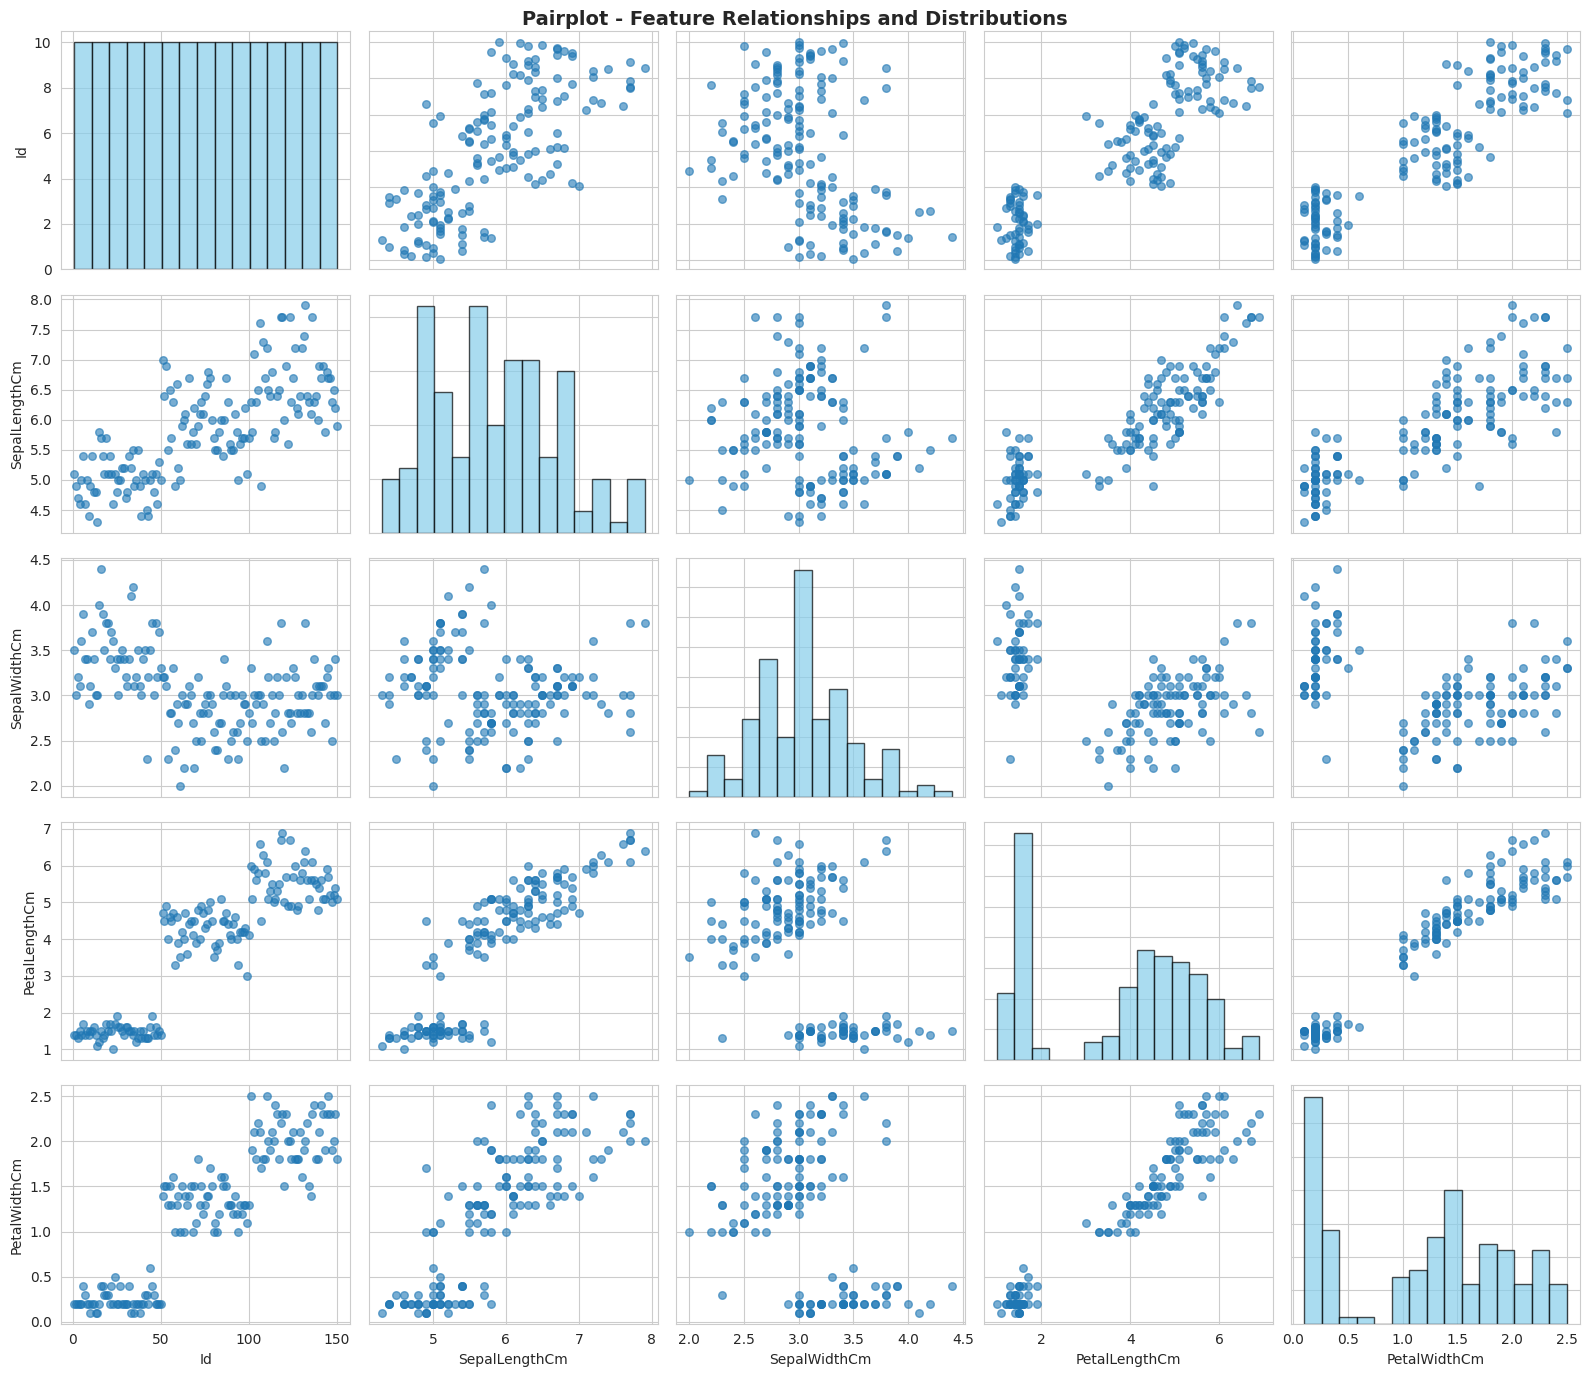

Pairplot generated successfully!


In [41]:
# Pairplot for distribution and relationship comparison
print("Creating pairplot for feature relationships...")
pairplot_df = df[numeric_features].copy()
# Create a simple pairplot manually using matplotlib
n_features = len(numeric_features)
fig, axes = plt.subplots(n_features, n_features, figsize=(16, 14))

# Ensure axes is always 2D even if n_features=1
if n_features == 1:
    axes = axes.reshape(1, 1)
elif n_features > 1:
    axes = axes.reshape(n_features, n_features)

for i, feature_y in enumerate(numeric_features):
    for j, feature_x in enumerate(numeric_features):
        ax = axes[i, j] if n_features > 1 else axes[0, 0]
        if i == j:
            # Diagonal: histogram
            ax.hist(df[feature_x], bins=15, color='skyblue', edgecolor='black', alpha=0.7)
        else:
            # Off-diagonal: scatter plot
            ax.scatter(df[feature_x], df[feature_y], alpha=0.6, s=30)
        
        if i == n_features - 1:
            ax.set_xlabel(feature_x, fontsize=10)
        else:
            ax.set_xticklabels([])
        
        if j == 0:
            ax.set_ylabel(feature_y, fontsize=10)
        else:
            ax.set_yticklabels([])

plt.suptitle('Pairplot - Feature Relationships and Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Pairplot generated successfully!")